In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
iris = datasets.load_iris()

# Features → (samples × features)
X = iris.data

# Labels → (samples,)
y = iris.target

print("Feature matrix shape:", X.shape)
print(X)

print("\nLabel vector shape:", y.shape)
print(y)

print("\nUnique classes:", np.unique(y))

Feature matrix shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]


In [3]:
mask = y < 2     # keep only class 0 and 1

X = X[mask]
y = y[mask]

print("Filtered X shape:", X.shape)
print("Filtered y shape:", y.shape)
print("Remaining classes:", np.unique(y))

Filtered X shape: (100, 4)
Filtered y shape: (100,)
Remaining classes: [0 1]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("Train X:", X_train.shape)
print("Test X:", X_test.shape)

Train X: (80, 4)
Test X: (20, 4)


In [5]:
class LogisticRegression:
    def __init__(self, eta=0.1, epochs=100):
        self.eta = eta          # learning rate (scalar)
        self.epochs = epochs    # number of passes
        self.theta = None       # (m+1 × 1)
        self.train_loss = []
        self.test_loss = []

    def sigmoid(self, z):
        # z = (n × 1) OR scalar
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, X, y):
        # X shape = (m+1 × n)
        # y shape = (n × 1)
        n = X.shape[1]   # number of examples

        # Xᵀ = (n × m+1) , θ  = (m+1 × 1)
        # Multiplication → (n × 1)
        z = np.dot(X.T, self.theta)

        # h = (n × 1)
        h = self.sigmoid(z)

        # avoid log(0)
        h = np.clip(h, 1e-10, 1 - 1e-10)

        # loss per example → (n × 1)
        loss = - ( y * np.log(h) + (1 - y) * np.log(1 - h) )

        # scalar
        return np.mean(loss)

    def fit(self, X_train, y_train, X_test, y_test):
        # Original X_train = (n × m)
        # Transpose → (m × n)
        X_train = X_train.T
        X_test = X_test.T

        # m = features, n = examples
        m, n = X_train.shape

        # Add bias row → X becomes (m+1 × n)
        X_train = np.vstack( (np.ones((1, n)), X_train) )
        X_test = np.vstack( (np.ones((1, X_test.shape[1])), X_test) )

        # y → (n × 1)
        y_train = y_train.reshape(n, 1)
        y_test = y_test.reshape(X_test.shape[1], 1)

        # θ = (m+1 × 1)
        self.theta = np.zeros((m + 1, 1))

        for _ in range(self.epochs):
            # ---------- FORWARD PASS ----------
            # Xᵀ = (n × m+1) , θ  = (m+1 × 1) , z = (n × 1)
            z = np.dot(X_train.T, self.theta)

            # h = (n × 1)
            h = self.sigmoid(z)

            # ---------- GRADIENT COMPUTATION ----------
            # X = (m+1 × n) , (h − y) = (n × 1)
            # → gradient = (m+1 × 1)
            gradient = np.dot(X_train, (h - y_train))

            # ---------- PARAMETER UPDATE ----------
            # θ = (m+1 × 1) , gradient = (m+1 × 1)
            self.theta -= self.eta * gradient

            # Track losses
            self.train_loss.append(self.compute_loss(X_train, y_train))
            self.test_loss.append(self.compute_loss(X_test, y_test))
  
  # Computes probabilities using sigmoid(Xᵀθ) and converts them to class labels.
  # Given learned θ, what class should each example belong to?
    def predict(self, X):
        # X originally = (n × m)
        # Transpose → (m × n)
        X = X.T

        # Add bias → (m+1 × n)
        X = np.vstack( (np.ones((1, X.shape[1])), X) )

        # Xᵀ = (n × m+1)
        # θ  = (m+1 × 1)
        # → probs = (n × 1)
        probs = self.sigmoid(np.dot(X.T, self.theta))

        # Convert probabilities → class labels
        # astype(int) converts True to 1 and False to 0
        # flatten() converts (n × 1) to (n,)
        return (probs >= 0.5).astype(int).flatten()

In [ ]:
model =LogisticRegression(eta=0.1, epochs=100)
model.fit(X_train, y_train, X_test, y_test)

print("Training complete")
print("Final Training Loss:", model.train_loss[-1])

Training complete
Final Training Loss: 1.022222834210456e-10


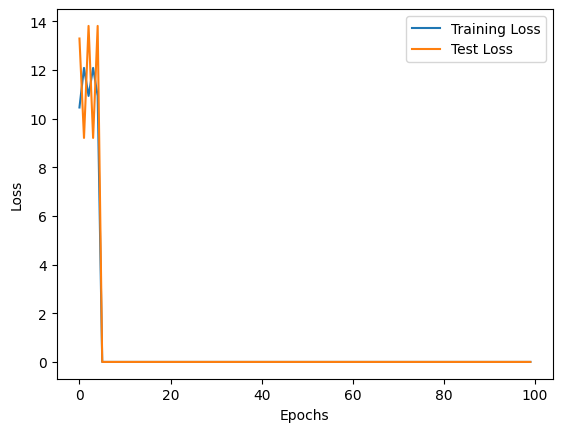

In [19]:
plt.plot(model.train_loss, label="Training Loss")
plt.plot(model.test_loss, label="Test Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
y_pred = model.predict(X_test)
print("Predictions:", y_pred)
print("True Labels:", y_test.flatten())

Predictions: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
True Labels: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]


In [21]:
cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nValues:")
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

# ----- Metrics -----
accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
precision = tp / (tp + fp) if (tp + fp) != 0 else 0

print("\nMetrics:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)

Confusion Matrix:
[[12  0]
 [ 0  8]]

Values:
TP: 8
TN: 12
FP: 0
FN: 0

Metrics:
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
